# **Providing data-driven suggestions for HR**

### HR dataset

The dataset 15,000 rows and 10 columns for the variables listed below. 

For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

This projects aim to improve employee satisfaction with data driven suggestions to HR

## Imports & Load Data

*   Import packages
*   Load dataset



In [82]:
# ----- Packages ------

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Data Modeling

# ----- Data ------
df = pd.read_csv('../data/HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Data Exploration (Initial EDA and data cleaning)

- Understand variables
- Clean my dataset (missing data, redundant data, outliers)



Check basic informations

In [83]:
# Basic information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [84]:
# Descriptive statistics about the data
df.describe(include='all')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


In [85]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [86]:
# We need to rename some columns
df = df.rename(columns={
    'Work_accident': 'work_accident',
    'average_montly_hours': 'average_monthly_hours',
    'time_spend_company': 'tenure',
    'Department': 'department'
})

# Display all column names after the update
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

**Check missing values**

In [87]:
# Missing values
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

No missing data 

**Check duplicates**

In [88]:
# Check for duplicates
df.duplicated().sum()

np.int64(3008)

~3000 duplicate is almost 20% our data

In [89]:
df[df.duplicated()].head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


It does not make sense different employee exactly reported same. That is why we will need to create another dataset withour duplicates, but we will keep original dataset in case it needed for  company.

In [90]:
# Drop duplicates
data = df.drop_duplicates(keep='first')
data.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


**Check outliers**

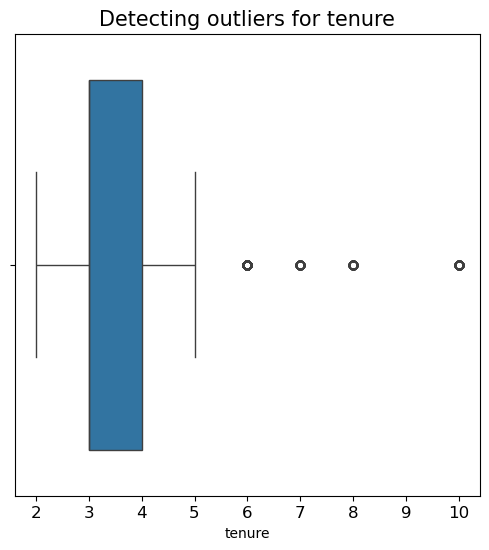

In [91]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
plt.figure(figsize=(6,6))
plt.title('Detecting outliers for tenure', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(data=data, x='tenure')
plt.show()

In [92]:
# number of rows containing outliers
percentile25 = data['tenure'].quantile(0.25)
percentile75 = data['tenure'].quantile(0.75)

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr 
print(f'Upper Limit: {upper_limit}')
print(f'Lower Limit: {lower_limit}')

outliers = data[(data['tenure'] > upper_limit) | (data['tenure'] < lower_limit)]
print(f'Total number of outliers of tenure is {len(outliers)}')

Upper Limit: 5.5
Lower Limit: 1.5
Total number of outliers of tenure is 824


## Data Exploration (Continue EDA)

- Understanding how many employees left and what percentage of all employees this figure represents.

In [93]:
#Number of people who left the job
print(data['left'].value_counts())
print('-------------------------')
#With percentages
print(data['left'].value_counts(normalize=True) * 100)


left
0    10000
1     1991
Name: count, dtype: int64
-------------------------
left
0    83.39588
1    16.60412
Name: proportion, dtype: float64


### Data visualizations

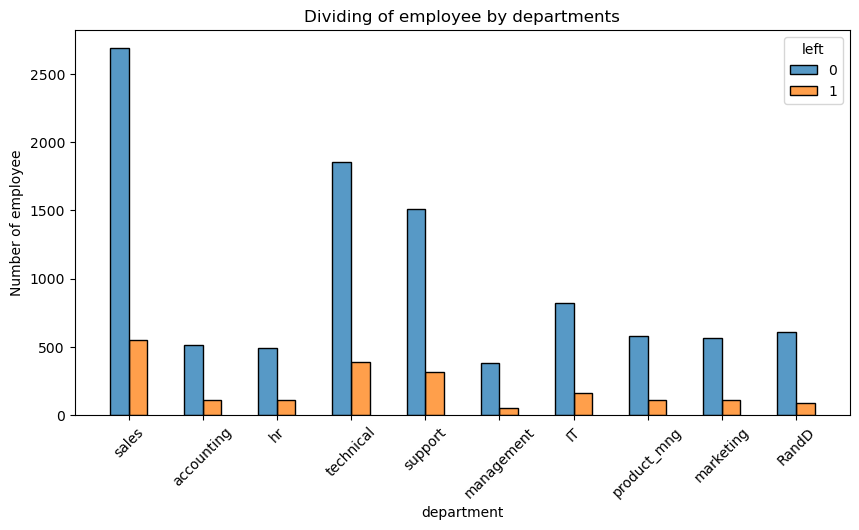

In [108]:
# department worker number
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.title('Dividing of employee by departments')
plt.ylabel('Number of employee')
plt.xticks(rotation=45)
plt.show()

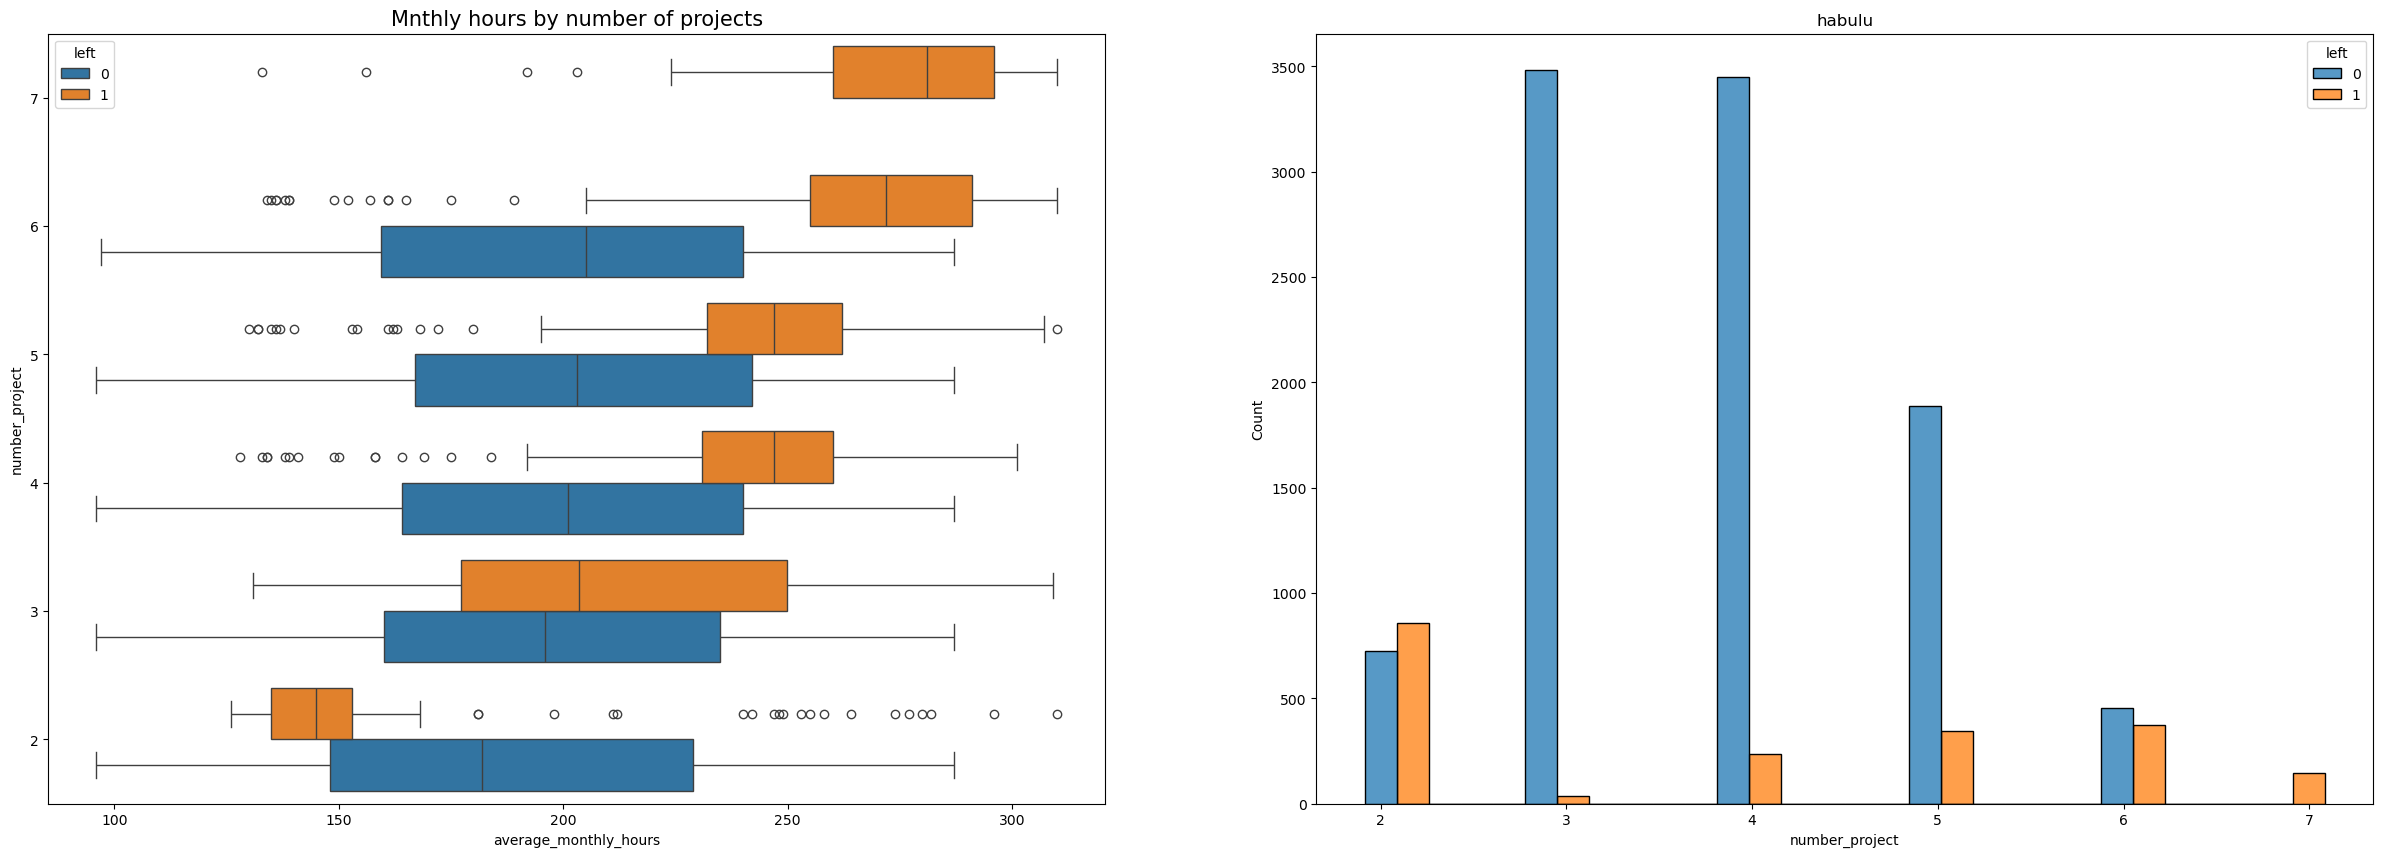

In [95]:
# 
fig, ax = plt.subplots(1, 2, figsize=(30,10))
sns.boxplot(data=data, x='average_monthly_hours', y='number_project', hue='left', orient='h', ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Mnthly hours by number of projects', fontsize=15)

temure_stay = data[data['left'] == 0]['number_project']
temure_left = data[data['left'] == 1]['number_project']
sns.histplot(data=data, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('habulu')

plt.show()

When employee has more projects naturally they works more hours. However there is two different group. Group1 who worked less than their collegues and fired (for example people who worked 2 project) and group2 those who worked much more. 

Everyone with 7 project left the company. As well as range of ~250-300 hours/month with 6 project also left the company. These give as some hints.

Optimal numbers are 3-4 projects becuse the ratio of left/stay is very small compating to others. 

Let's assume in a week we work 40hours Monday to Friday, ~50 weeks in a year. 
`50 weeks * 40 hours / 12 months = ~167 hours`. With charts we see that even who did not leave company is worked more hours.


In [96]:
data[data['number_project'] == 7]['left'].value_counts()

left
1    145
Name: count, dtype: int64

As we can see everyone (145 person) with 7 project left the company because they are owerworked

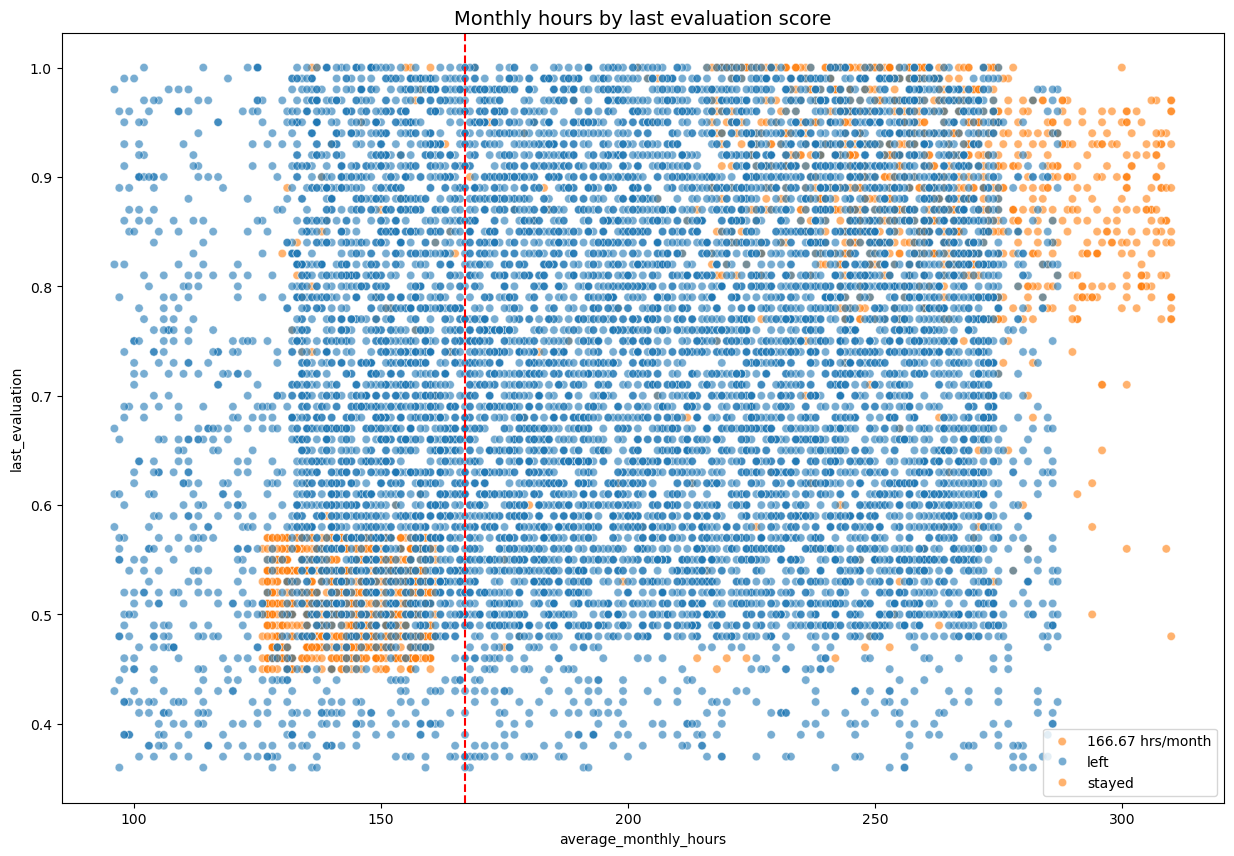

In [97]:
# scatterplot of `average_monthly_hours` versus `last_evaluation`
plt.figure(figsize=(15,10))
sns.scatterplot(data=data, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.6)
plt.axvline(x=167, color='red', label='167 hrs/month', ls='--')
plt.legend(labels=['166.67 hrs/month', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');


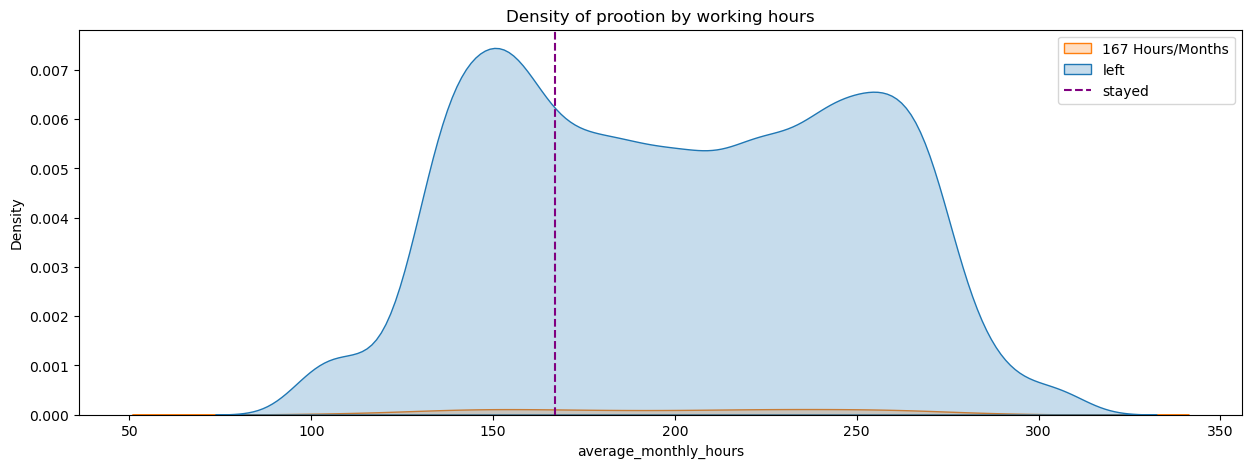

In [98]:
# Create plot to examine relationship between `average_monthly_hours` and `promotion_last_5years`
plt.figure(figsize=(15,5))
sns.kdeplot(data=data, x='average_monthly_hours', hue='promotion_last_5years', fill=True)
plt.title('Density of prootion by working hours')
plt.axvline(x=167, color='purple', label='167 Hours/Months', ls='--')
plt.legend(labels=['167 Hours/Months', 'left', 'stayed'])
plt.show()

Very little amount of people promoted.
Very few people promoted who worked long hours


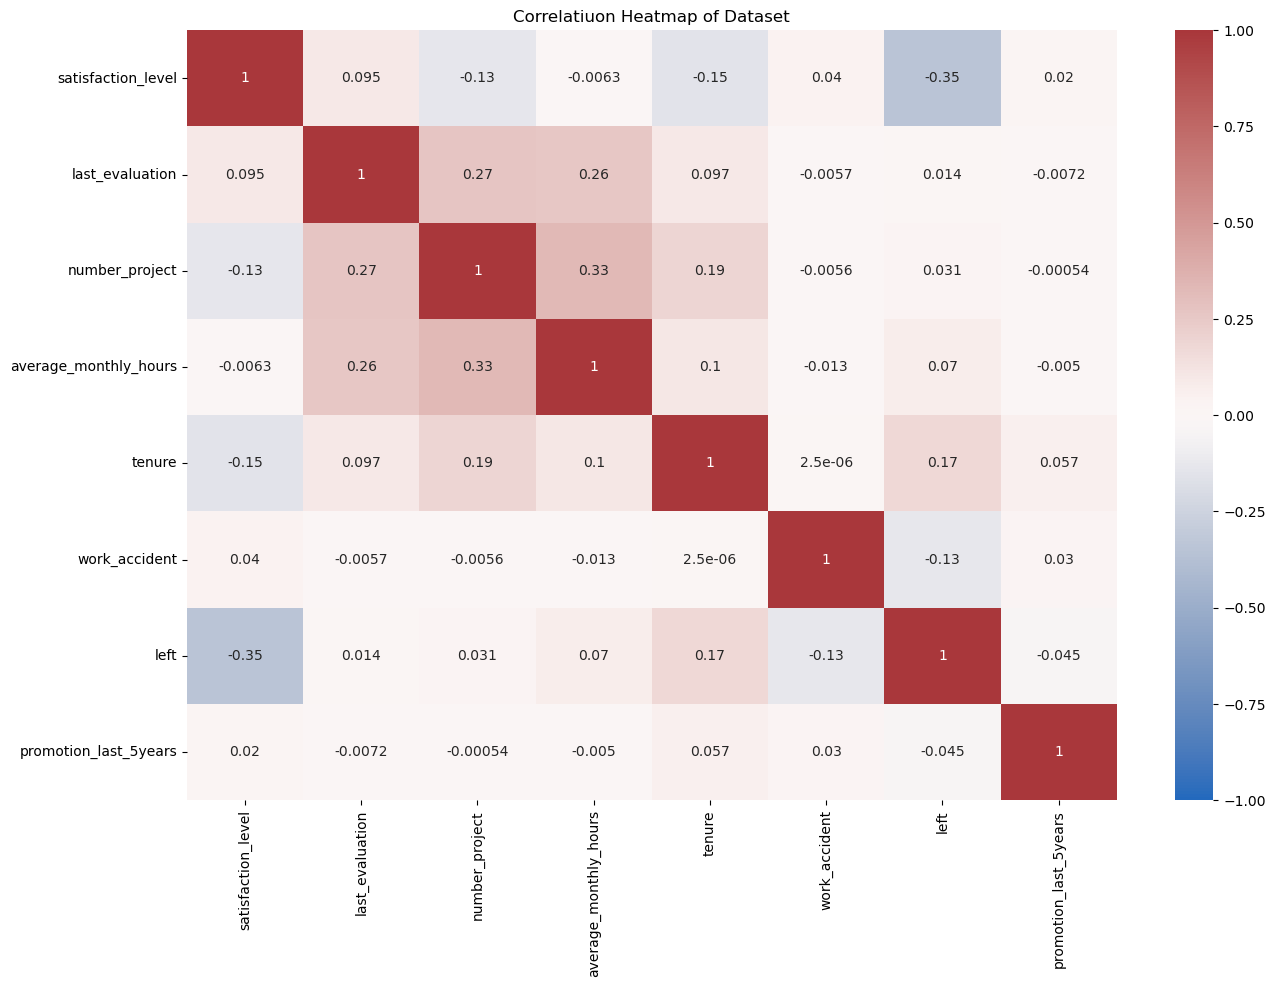

In [99]:
# Create a plot as needed
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(numeric_only=True), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
plt.title('Correlatiuon Heatmap of Dataset')
plt.show()

Correlation map show that, high number of projects has negative affect on satisfaction level. Also, avarage monthly hours, number of project and last evaluation is correlated positevely.
We can say that, employee leaves because of:
- Longer working hours
- High number of projects
- Not receiving promotions / evaluation while urned out from overworking.

## Model Building
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model
- Logistic Regression Model

In [100]:
# department and salary is non numeric columns
# We can dummy department, however for salary it has some level inside like hieararchy. That is why we can convert it to numbers

# Copy of data
data1 = data.copy()

# Encoding of salary --- I get a help from AI at this point after getting errors :)
data1['salary'] = (
    data1['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes 
)

# dummy department
data1 = pd.get_dummies(data1, columns=['department'], drop_first=False)
data1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


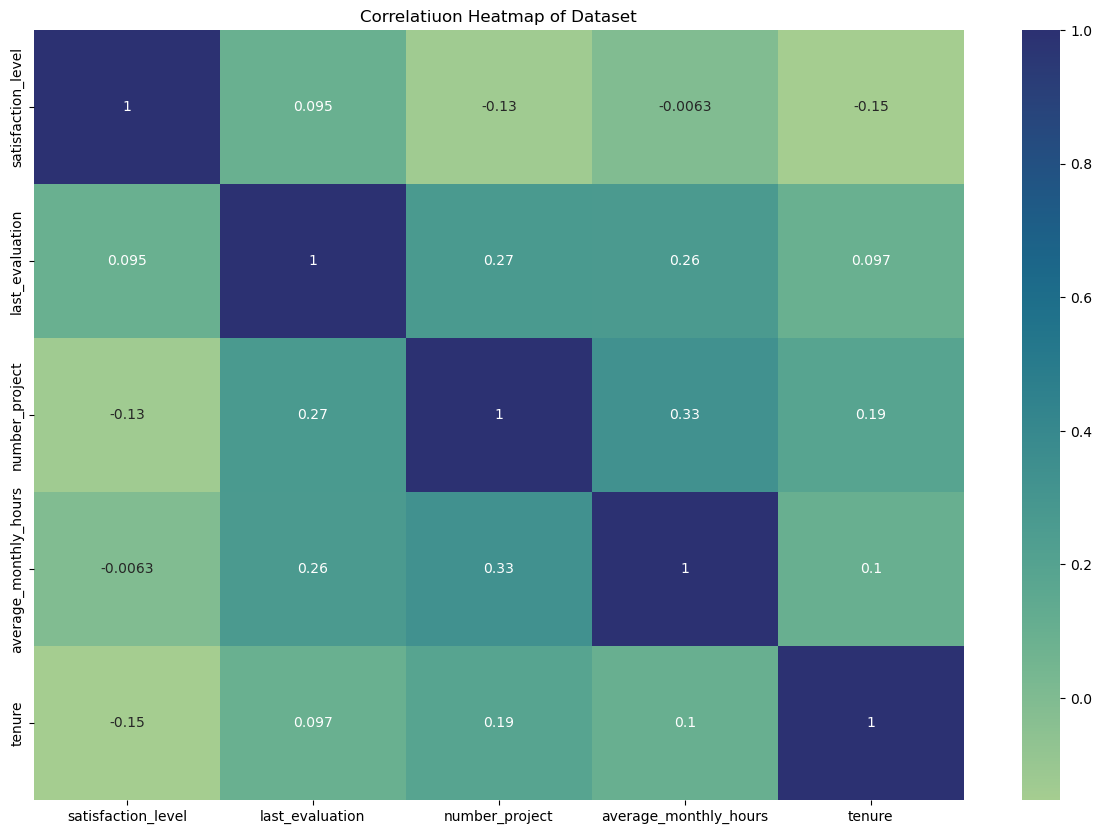

In [ ]:
# Correlation heatmap 
plt.figure(figsize=(15,10))
sns.heatmap(data[['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure']]
            .corr(numeric_only=True), annot=True, 
            cmap=sns.color_palette("crest", as_cmap=True))
plt.title('Correlatiuon Heatmap of Dataset')
plt.show()

In [110]:
# For regression model we need to drop outliers from 'tenure'
df_reg = data1[(data1['tenure'] >= lower_limit) & (data1['tenure'] <= upper_limit)]
df_reg.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Double-click to enter your responses here.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

[Double-click to enter your summary here.]

### Conclusion, Recommendations, Next Steps

[Double-click to enter your conclusion, recommendations, and next steps here.]

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.